# 📊 Análisis Exploratorio del Desempeño Económico del Micronegocio Colombiano
## EMICRON 2019-2024 — DANE

### Proyecto: Desarrollo Social y Económico — Universidad Santo Tomás
**Fecha:** Mayo 2026 | **Fuente:** Encuesta de Micronegocios (EMICRON) — DANE


## 1. Introducción

El presente análisis explora el desempeño económico de los micronegocios colombianos a partir de los datos de la Encuesta de Micronegocios (EMICRON) del DANE para el período 2019-2024. Los micronegocios constituyen el tejido productivo más amplio del país, representando más del 90% de las unidades económicas y siendo fuente principal de empleo e ingresos para los hogares más vulnerables.

El análisis busca responder las siguientes preguntas:
- ¿Cuál es el nivel de ingresos y rentabilidad de los micronegocios colombianos?
- ¿Cómo evolucionó el desempeño económico entre 2019 y 2024, incluyendo el impacto del COVID-19?
- ¿Existen diferencias significativas entre departamentos, tipos de persona y niveles de formalización?
- ¿Existe relación entre la inversión pública (SECOP) y el desempeño del micronegocio?




## 2. Metodología

**Fuente de datos:** EMICRON 2019-2024 — DANE  
**Unidad de análisis:** Micronegocio (establecimiento con hasta 9 personas ocupadas)  
**Cobertura geográfica:** 24-25 departamentos con representación estadística  
**Variables principales:**
- `VENTAS_MES_ANTERIOR` — Ingresos del mes anterior (COP)
- `COSTOS_MES_ANTERIOR` — Costos del mes anterior (COP)
- `F_EXP` — Factor de expansión (ponderador muestral)
- `P3031` — Tipo de persona (1=Natural, 2=Jurídica)
- `P3000` — Registro mercantil (1=Registrado, 2=No registrado)

**Nota metodológica:** Todos los indicadores se calculan aplicando el factor de expansión `F_EXP`, lo que permite obtener estimaciones representativas de la población total de micronegocios en cada departamento.

---

## 3. Hallazgos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings, glob

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DEPTOS = {
    5:'Antioquia', 8:'Atlántico', 11:'Bogotá D.C.', 13:'Bolívar',
    15:'Boyacá', 17:'Caldas', 18:'Caquetá', 19:'Cauca', 20:'Cesar',
    23:'Córdoba', 25:'Cundinamarca', 27:'Chocó', 41:'Huila',
    44:'La Guajira', 47:'Magdalena', 50:'Meta', 52:'Nariño',
    54:'N. de Santander', 63:'Quindío', 66:'Risaralda', 68:'Santander',
    70:'Sucre', 73:'Tolima', 76:'Valle del Cauca', 81:'Arauca',
    85:'Casanare', 86:'Putumayo', 88:'San Andrés', 91:'Amazonas',
    94:'Guainía', 95:'Guaviare', 97:'Vaupés', 99:'Vichada'
}

def wmean(df, col, weight='F_EXP'):
    w = df[weight].fillna(1)
    return np.average(df[col].fillna(0), weights=w)

print('Librerías OK')

Librerías OK


# CARGA Y PREPARACIÓN DE DATOS

In [2]:
BRONZE_PATH = '../datos/bronze/emicron'
ANOS = [2019, 2020, 2021, 2022, 2023, 2024]
dfs_v, dfs_c, dfs_i = [], [], []

for año in ANOS:
    v = glob.glob(f'{BRONZE_PATH}/{año}/*ventas*{año}*.parquet')
    c = glob.glob(f'{BRONZE_PATH}/{año}/*costos*{año}*.parquet')
    i = glob.glob(f'{BRONZE_PATH}/{año}/*identificac*{año}*.parquet')
    if v: dfs_v.append(pd.read_parquet(v[0]))
    if c: dfs_c.append(pd.read_parquet(c[0]))
    if i: dfs_i.append(pd.read_parquet(i[0]))

ventas_raw = pd.concat(dfs_v, ignore_index=True)
costos_raw = pd.concat(dfs_c, ignore_index=True)
ident_raw  = pd.concat(dfs_i, ignore_index=True)

LLAVES = ['DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P']
ventas = ventas_raw[LLAVES + ['VENTAS_MES_ANTERIOR', '_emicron_year']].copy()
costos = costos_raw[LLAVES + ['COSTOS_MES_ANTERIOR']].copy()
cols_i = LLAVES + ['COD_DEPTO', 'F_EXP', '_emicron_year'] + [c for c in ['P3031','P3000'] if c in ident_raw.columns]
ident  = ident_raw[cols_i].copy()

df = ventas.merge(costos[LLAVES+['COSTOS_MES_ANTERIOR']], on=LLAVES, how='left')
df = df.merge(ident, on=LLAVES, how='left')
df['anio'] = df['_emicron_year_x'].astype(int)
df['VENTAS_MES_ANTERIOR'] = pd.to_numeric(df['VENTAS_MES_ANTERIOR'], errors='coerce').fillna(0)
df['COSTOS_MES_ANTERIOR'] = pd.to_numeric(df['COSTOS_MES_ANTERIOR'], errors='coerce').fillna(0)
df['F_EXP']     = pd.to_numeric(df.get('F_EXP', pd.Series([1]*len(df))), errors='coerce').fillna(1)
df['COD_DEPTO'] = pd.to_numeric(df.get('COD_DEPTO', pd.Series([np.nan]*len(df))), errors='coerce')

# Indicadores derivados
df['UTILIDAD']     = df['VENTAS_MES_ANTERIOR'] - df['COSTOS_MES_ANTERIOR']
df['MARGEN_PCT']   = np.where(df['VENTAS_MES_ANTERIOR']>0, df['UTILIDAD']/df['VENTAS_MES_ANTERIOR']*100, np.nan)
df['TIENE_VENTAS'] = df['VENTAS_MES_ANTERIOR'] > 0
df['ES_RENTABLE']  = df['UTILIDAD'] > 0

if 'P3031' in df.columns: df['TIPO_PERSONA'] = df['P3031'].map({1:'Natural', 2:'Jurídica/Otro'})
if 'P3000' in df.columns: df['FORMALIZADO']  = df['P3000'].map({1:'Registrado', 2:'No registrado'})
df['NOMBRE_DEPTO'] = df['COD_DEPTO'].map(DEPTOS)

print(f'Dataset listo: {len(df):,} registros')
print(f'   Años:          {sorted(df["anio"].unique().tolist())}')
print(f'   Departamentos: {df["NOMBRE_DEPTO"].nunique()}')
print(f'   Negocios activos (ventas > 0): {df.TIENE_VENTAS.mean()*100:.1f}%')

Dataset listo: 496,274 registros
   Años:          [2019, 2020, 2021, 2022, 2023, 2024]
   Departamentos: 25
   Negocios activos (ventas > 0): 92.2%


### 3.1 Estadísticas Descriptivas

Las estadísticas descriptivas permiten tener un primer vistazo al comportamiento general del desempeño económico de los micronegocios. Se presentan medidas de tendencia central (media y mediana) y dispersión (desviación estándar y percentiles) para ingresos, costos, utilidad y margen de utilidad.

In [3]:
print('=' * 65)
print('INDICADOR: DESEMPEÑO ECONÓMICO DEL MICRONEGOCIO COLOMBIANO')
print('Fuente: EMICRON 2019-2024 — DANE')
print('=' * 65)

print('\n📊 TABLA 1: Estadísticas Descriptivas de Variables Económicas')
print('─' * 65)
print('Interpretación: Se presentan medidas de tendencia central')
print('y dispersión para las variables económicas principales.')
print('Los valores están en pesos colombianos (COP).\n')

desc = df[['VENTAS_MES_ANTERIOR','COSTOS_MES_ANTERIOR','UTILIDAD','MARGEN_PCT']].describe(
    percentiles=[.10,.25,.50,.75,.90])
desc.columns = ['Ingresos (COP)', 'Costos (COP)', 'Utilidad (COP)', 'Margen (%)']
print(desc.round(0).to_string())

print('\n📌 INDICADORES CLAVE:')
print('─' * 65)
print(f'  • Negocios con ventas > 0:    {df.TIENE_VENTAS.mean()*100:.1f}%')
print(f'  • Negocios rentables:          {df.ES_RENTABLE.mean()*100:.1f}%')
print(f'  • Ingreso mediano mensual:     ${df.loc[df.TIENE_VENTAS,"VENTAS_MES_ANTERIOR"].median():,.0f} COP')
print(f'  • Costo mediano mensual:       ${df.loc[df.TIENE_VENTAS,"COSTOS_MES_ANTERIOR"].median():,.0f} COP')
print(f'  • Utilidad mediana mensual:    ${df.loc[df.TIENE_VENTAS,"UTILIDAD"].median():,.0f} COP')
print(f'  • Margen de utilidad mediano:  {df.MARGEN_PCT.median():.1f}%')

print('\n💡 INTERPRETACIÓN:')
print('─' * 65)
print(f'  La mediana de ingresos es significativamente menor que la media,')
print(f'  lo que indica que la distribución está sesgada hacia la derecha:')
print(f'  unos pocos micronegocios con ingresos muy altos elevan el promedio.')
print(f'  El {df.TIENE_VENTAS.mean()*100:.1f}% de negocios reportó actividad económica,')
print(f'  y de esos, el {df.loc[df.TIENE_VENTAS,"ES_RENTABLE"].mean()*100:.1f}% opera con utilidad positiva.')

INDICADOR: DESEMPEÑO ECONÓMICO DEL MICRONEGOCIO COLOMBIANO
Fuente: EMICRON 2019-2024 — DANE

📊 TABLA 1: Estadísticas Descriptivas de Variables Económicas
─────────────────────────────────────────────────────────────────
Interpretación: Se presentan medidas de tendencia central
y dispersión para las variables económicas principales.
Los valores están en pesos colombianos (COP).

       Ingresos (COP)  Costos (COP)  Utilidad (COP)  Margen (%)
count    4.962740e+05      496274.0        496274.0    457791.0
mean     2.446538e+06     1128772.0       1317766.0        61.0
std      8.102909e+06     5704849.0       4527400.0       252.0
min      0.000000e+00           0.0    -435000000.0    -67400.0
10%      8.993000e+04           0.0         25000.0        29.0
25%      4.333330e+05       20000.0        250000.0        47.0
50%      1.000000e+06      230000.0        700000.0        69.0
75%      2.200000e+06      800000.0       1420000.0        92.0
90%      5.000000e+06     2000000.0       2

> **Nota de lectura:** La diferencia entre media y mediana indica el grado de asimetría de la distribución. Cuando la media es mayor que la mediana, la distribución está sesgada hacia la derecha — es decir, hay pocos negocios con ingresos muy altos que elevan el promedio.

### 3.2 Distribución de Ingresos, Costos y Utilidad

Los histogramas muestran la forma de la distribución de las tres variables económicas principales. Se excluyen los valores del percentil 99 para una mejor visualización, evitando que los valores extremos distorsionen la escala.

**¿Qué observar?**
- La forma de la distribución (simétrica vs sesgada)
- La distancia entre media y mediana
- La proporción de negocios cerca del punto de equilibrio (utilidad = 0)

📊 FIGURA 1: Distribución del Desempeño Económico del Micronegocio
Línea roja = mediana | Línea naranja = media



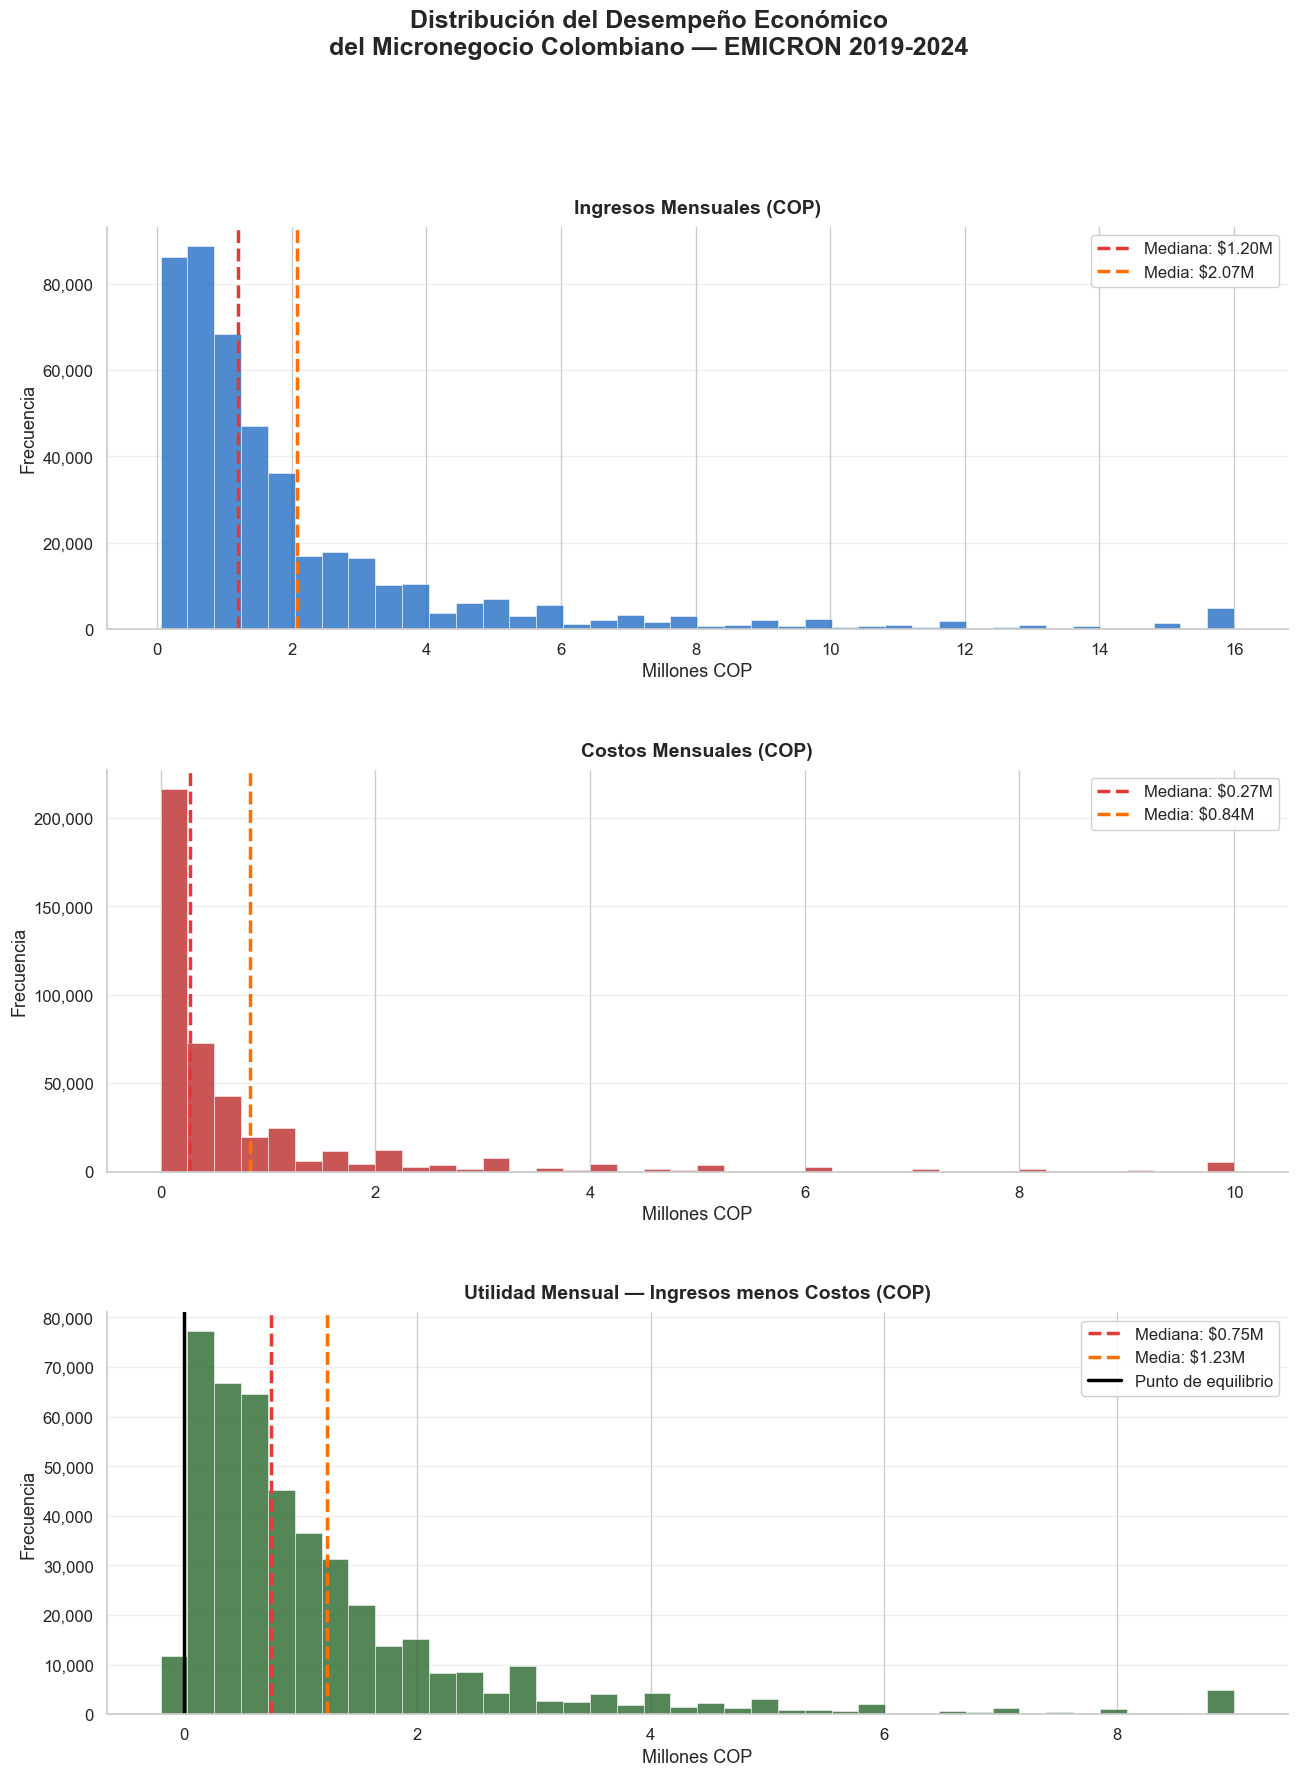


💡 INTERPRETACIÓN:
─────────────────────────────────────────────────────────────────
  • Ingresos: distribución sesgada a la derecha — mayoría gana
    menos de $2M/mes, pocos superan $5M.
  • Costos: concentrados cerca de cero, con cola larga.
  • Utilidad: muchos negocios cerca del punto de equilibrio (0),
    con más negocios rentables que en pérdida.


In [4]:
# ============================================================
# FIGURA 1 — DISTRIBUCIÓN DE INGRESOS, COSTOS Y UTILIDAD
# ============================================================

print('📊 FIGURA 1: Distribución del Desempeño Económico del Micronegocio')
print('Línea roja = mediana | Línea naranja = media\n')

df_act  = df[df.TIENE_VENTAS]
p99     = df_act['VENTAS_MES_ANTERIOR'].quantile(0.99)
df_plot = df_act[df_act.VENTAS_MES_ANTERIOR <= p99]

configs = [
    ('VENTAS_MES_ANTERIOR', '#1565C0', 'Ingresos Mensuales (COP)'),
    ('COSTOS_MES_ANTERIOR', '#B71C1C', 'Costos Mensuales (COP)'),
    ('UTILIDAD',            '#1B5E20', 'Utilidad Mensual — Ingresos menos Costos (COP)')
]

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle(
    'Distribución del Desempeño Económico\ndel Micronegocio Colombiano — EMICRON 2019-2024',
    fontsize=18, fontweight='bold', y=1.01
)

for ax, (col, color, titulo) in zip(axes, configs):
    datos = df_plot[col].clip(df_plot[col].quantile(0.01), df_plot[col].quantile(0.99))
    ax.hist(datos/1e6, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    med = datos.median()/1e6
    mea = datos.mean()/1e6
    ax.axvline(med, color='#E53935', ls='--', lw=2.5, label=f'Mediana: ${med:.2f}M')
    ax.axvline(mea, color='#FF6F00', ls='--', lw=2.5, label=f'Media: ${mea:.2f}M')
    if col == 'UTILIDAD':
        ax.axvline(0, color='black', lw=2.5, label='Punto de equilibrio')
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Millones COP', fontsize=13)
    ax.set_ylabel('Frecuencia', fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout(pad=4)
plt.savefig('../notebooks/fig1_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('─' * 65)
print('  • Ingresos: distribución sesgada a la derecha — mayoría gana')
print('    menos de $2M/mes, pocos superan $5M.')
print('  • Costos: concentrados cerca de cero, con cola larga.')
print('  • Utilidad: muchos negocios cerca del punto de equilibrio (0),')
print('    con más negocios rentables que en pérdida.')

### 3.3 Evolución Temporal 2019-2024

El análisis temporal permite identificar tendencias de largo plazo y el impacto de eventos externos como la pandemia COVID-19 (2020-2021). Se presentan cuatro indicadores clave: ingresos y costos ponderados, utilidad promedio, margen de utilidad mediano y porcentaje de negocios rentables.

> **Zona gris:** Representa el período de pandemia COVID-19 (2020-2021), caracterizado por restricciones a la movilidad y caída de la demanda que afectaron significativamente a los micronegocios.

📊 FIGURA 2: Evolución Temporal del Desempeño Económico
─────────────────────────────────────────────────────────────────
La zona gris representa el período de pandemia COVID-19.



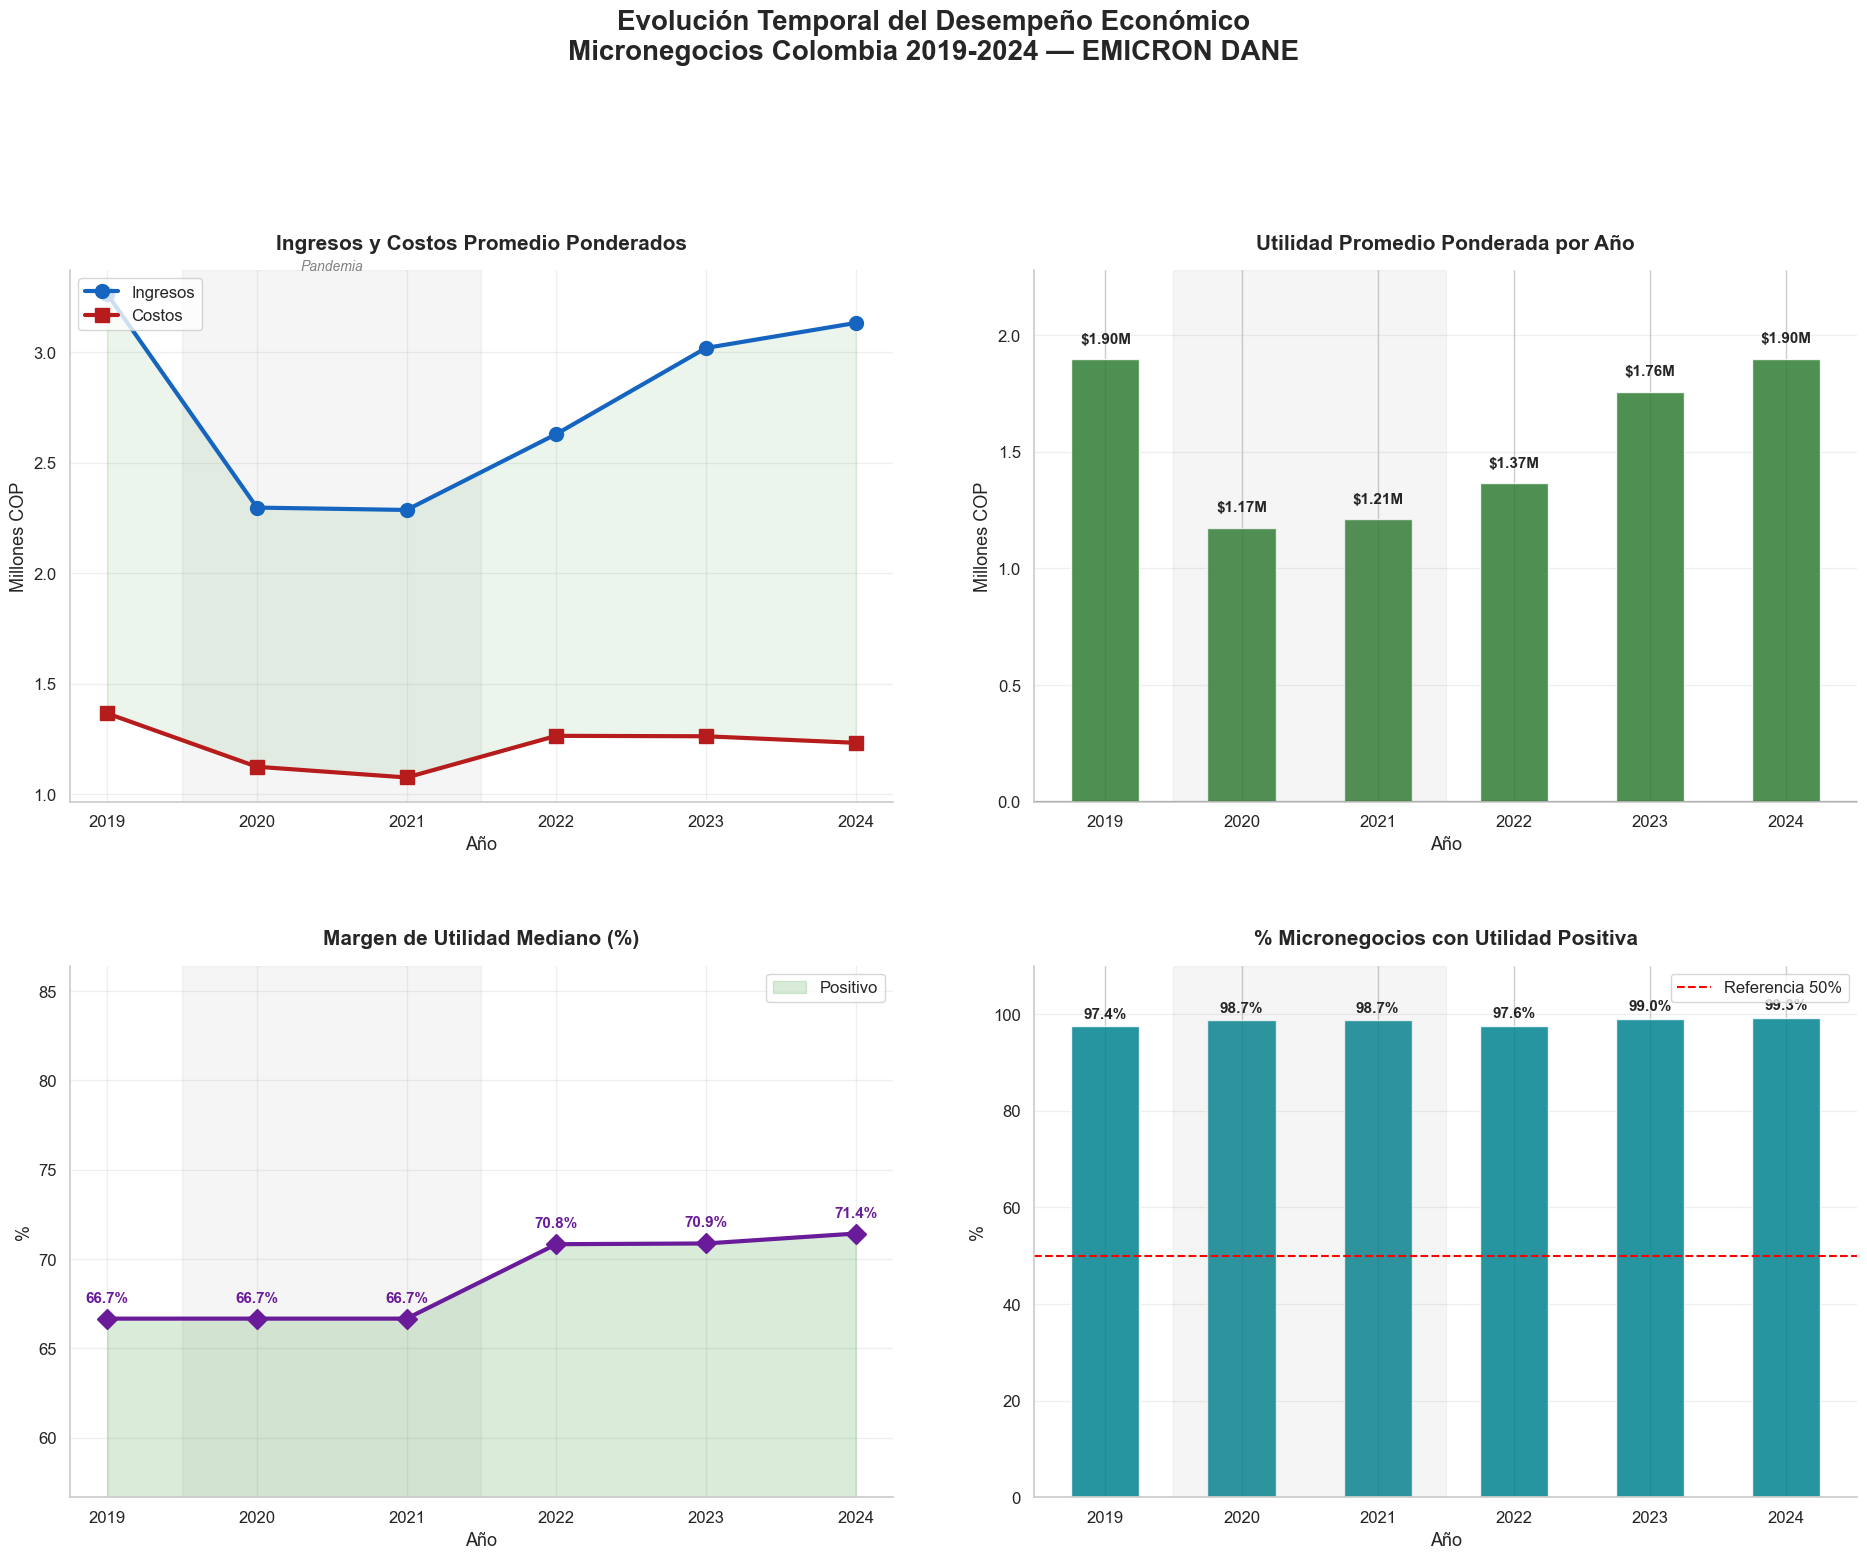


💡 INTERPRETACIÓN:
─────────────────────────────────────────────────────────────────
  • Los ingresos crecen sostenidamente de 2019 a 2024.
  • El impacto del COVID-19 (2020-2021) se refleja en caída
    de ingresos y menor proporción de negocios rentables.
  • La recuperación post-pandemia (2022-2024) es evidente.
  • El margen de utilidad se mantiene positivo en todos los años.


In [5]:
# ============================================================
# FIGURA 2 — EVOLUCIÓN TEMPORAL 2019-2024
# ============================================================

print('📊 FIGURA 2: Evolución Temporal del Desempeño Económico')
print('─' * 65)
print('La zona gris representa el período de pandemia COVID-19.\n')

temporal = []
for año, grp in df[df.TIENE_VENTAS].groupby('anio'):
    temporal.append({
        'anio':     int(año),
        'ingreso':  wmean(grp, 'VENTAS_MES_ANTERIOR'),
        'costo':    wmean(grp, 'COSTOS_MES_ANTERIOR'),
        'utilidad': wmean(grp, 'UTILIDAD'),
        'margen':   grp['MARGEN_PCT'].median(),
        'pct_rent': grp['ES_RENTABLE'].mean() * 100
    })
df_t = pd.DataFrame(temporal).sort_values('anio')

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(
    'Evolución Temporal del Desempeño Económico\n'
    'Micronegocios Colombia 2019-2024 — EMICRON DANE',
    fontsize=20, fontweight='bold', y=1.01
)

# ── Gráfico 1: Ingresos vs Costos ──────────────────────────
ax = axes[0, 0]
ax.plot(df_t.anio, df_t.ingreso/1e6, 'o-', color='#1565C0', lw=3, ms=10, label='Ingresos')
ax.plot(df_t.anio, df_t.costo/1e6,   's-', color='#B71C1C', lw=3, ms=10, label='Costos')
ax.fill_between(df_t.anio, df_t.ingreso/1e6, df_t.costo/1e6, alpha=0.08, color='green')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray')
ax.text(2020.5, ax.get_ylim()[1] if ax.get_ylim()[1] else 3,
        'Pandemia', ha='center', fontsize=10, color='gray', style='italic')
ax.set_title('Ingresos y Costos Promedio Ponderados', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Millones COP', fontsize=13)
ax.set_xlabel('Año', fontsize=13)
ax.set_xticks(df_t.anio)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.grid(alpha=0.3)
for s in ['top','right']: ax.spines[s].set_visible(False)

# ── Gráfico 2: Utilidad ─────────────────────────────────────
ax = axes[0, 1]
colores_u = ['#2E7D32' if u > 0 else '#C62828' for u in df_t.utilidad]
bars = ax.bar(df_t.anio, df_t.utilidad/1e6, color=colores_u, alpha=0.85, width=0.5)
ax.axhline(0, color='black', lw=1.5)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray')
# Etiquetas encima de las barras con espacio suficiente
for bar, util in zip(bars, df_t.utilidad):
    ax.text(bar.get_x() + bar.get_width()/2,
            util/1e6 + max(df_t.utilidad/1e6)*0.03,
            f'${util/1e6:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, df_t.utilidad.max()/1e6 * 1.2)
ax.set_title('Utilidad Promedio Ponderada por Año', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Millones COP', fontsize=13)
ax.set_xlabel('Año', fontsize=13)
ax.set_xticks(df_t.anio)
ax.tick_params(labelsize=12)
ax.grid(axis='y', alpha=0.3)
for s in ['top','right']: ax.spines[s].set_visible(False)

# ── Gráfico 3: Margen ──────────────────────────────────────
ax = axes[1, 0]
ax.plot(df_t.anio, df_t.margen, 'D-', color='#6A1B9A', lw=3, ms=10)
ax.fill_between(df_t.anio, df_t.margen, 0,
                where=(df_t.margen >= 0), alpha=0.15, color='green', label='Positivo')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray')
for año, m in zip(df_t.anio, df_t.margen):
    ax.annotate(f'{m:.1f}%', xy=(año, m),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold', color='#6A1B9A')
ax.set_ylim(df_t.margen.min() - 10, df_t.margen.max() + 15)
ax.set_title('Margen de Utilidad Mediano (%)', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('%', fontsize=13)
ax.set_xlabel('Año', fontsize=13)
ax.set_xticks(df_t.anio)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
for s in ['top','right']: ax.spines[s].set_visible(False)

# ── Gráfico 4: % Rentables ─────────────────────────────────
ax = axes[1, 1]
bars2 = ax.bar(df_t.anio, df_t.pct_rent, color='#00838F', alpha=0.85, width=0.5)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray')
ax.axhline(50, color='red', lw=1.5, ls='--', label='Referencia 50%')
for bar, p in zip(bars2, df_t.pct_rent):
    ax.text(bar.get_x() + bar.get_width()/2,
            p + 1, f'{p:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title('% Micronegocios con Utilidad Positiva', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('%', fontsize=13)
ax.set_xlabel('Año', fontsize=13)
ax.set_xticks(df_t.anio)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.tight_layout(pad=5)
plt.savefig('../notebooks/fig2_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('─' * 65)
print('  • Los ingresos crecen sostenidamente de 2019 a 2024.')
print('  • El impacto del COVID-19 (2020-2021) se refleja en caída')
print('    de ingresos y menor proporción de negocios rentables.')
print('  • La recuperación post-pandemia (2022-2024) es evidente.')
print('  • El margen de utilidad se mantiene positivo en todos los años.')

### 3.4 Desempeño Económico por Departamento

El análisis territorial revela la heterogeneidad existente entre los departamentos colombianos. Se comparan el ingreso promedio mensual ponderado y el margen de utilidad mediano para identificar cuáles departamentos tienen los micronegocios más competitivos.

> **Lectura del gráfico:** El tamaño y color de las barras permite identificar de forma inmediata los departamentos con mejor y peor desempeño relativo.

📊 FIGURA 3: Desempeño Económico por Departamento



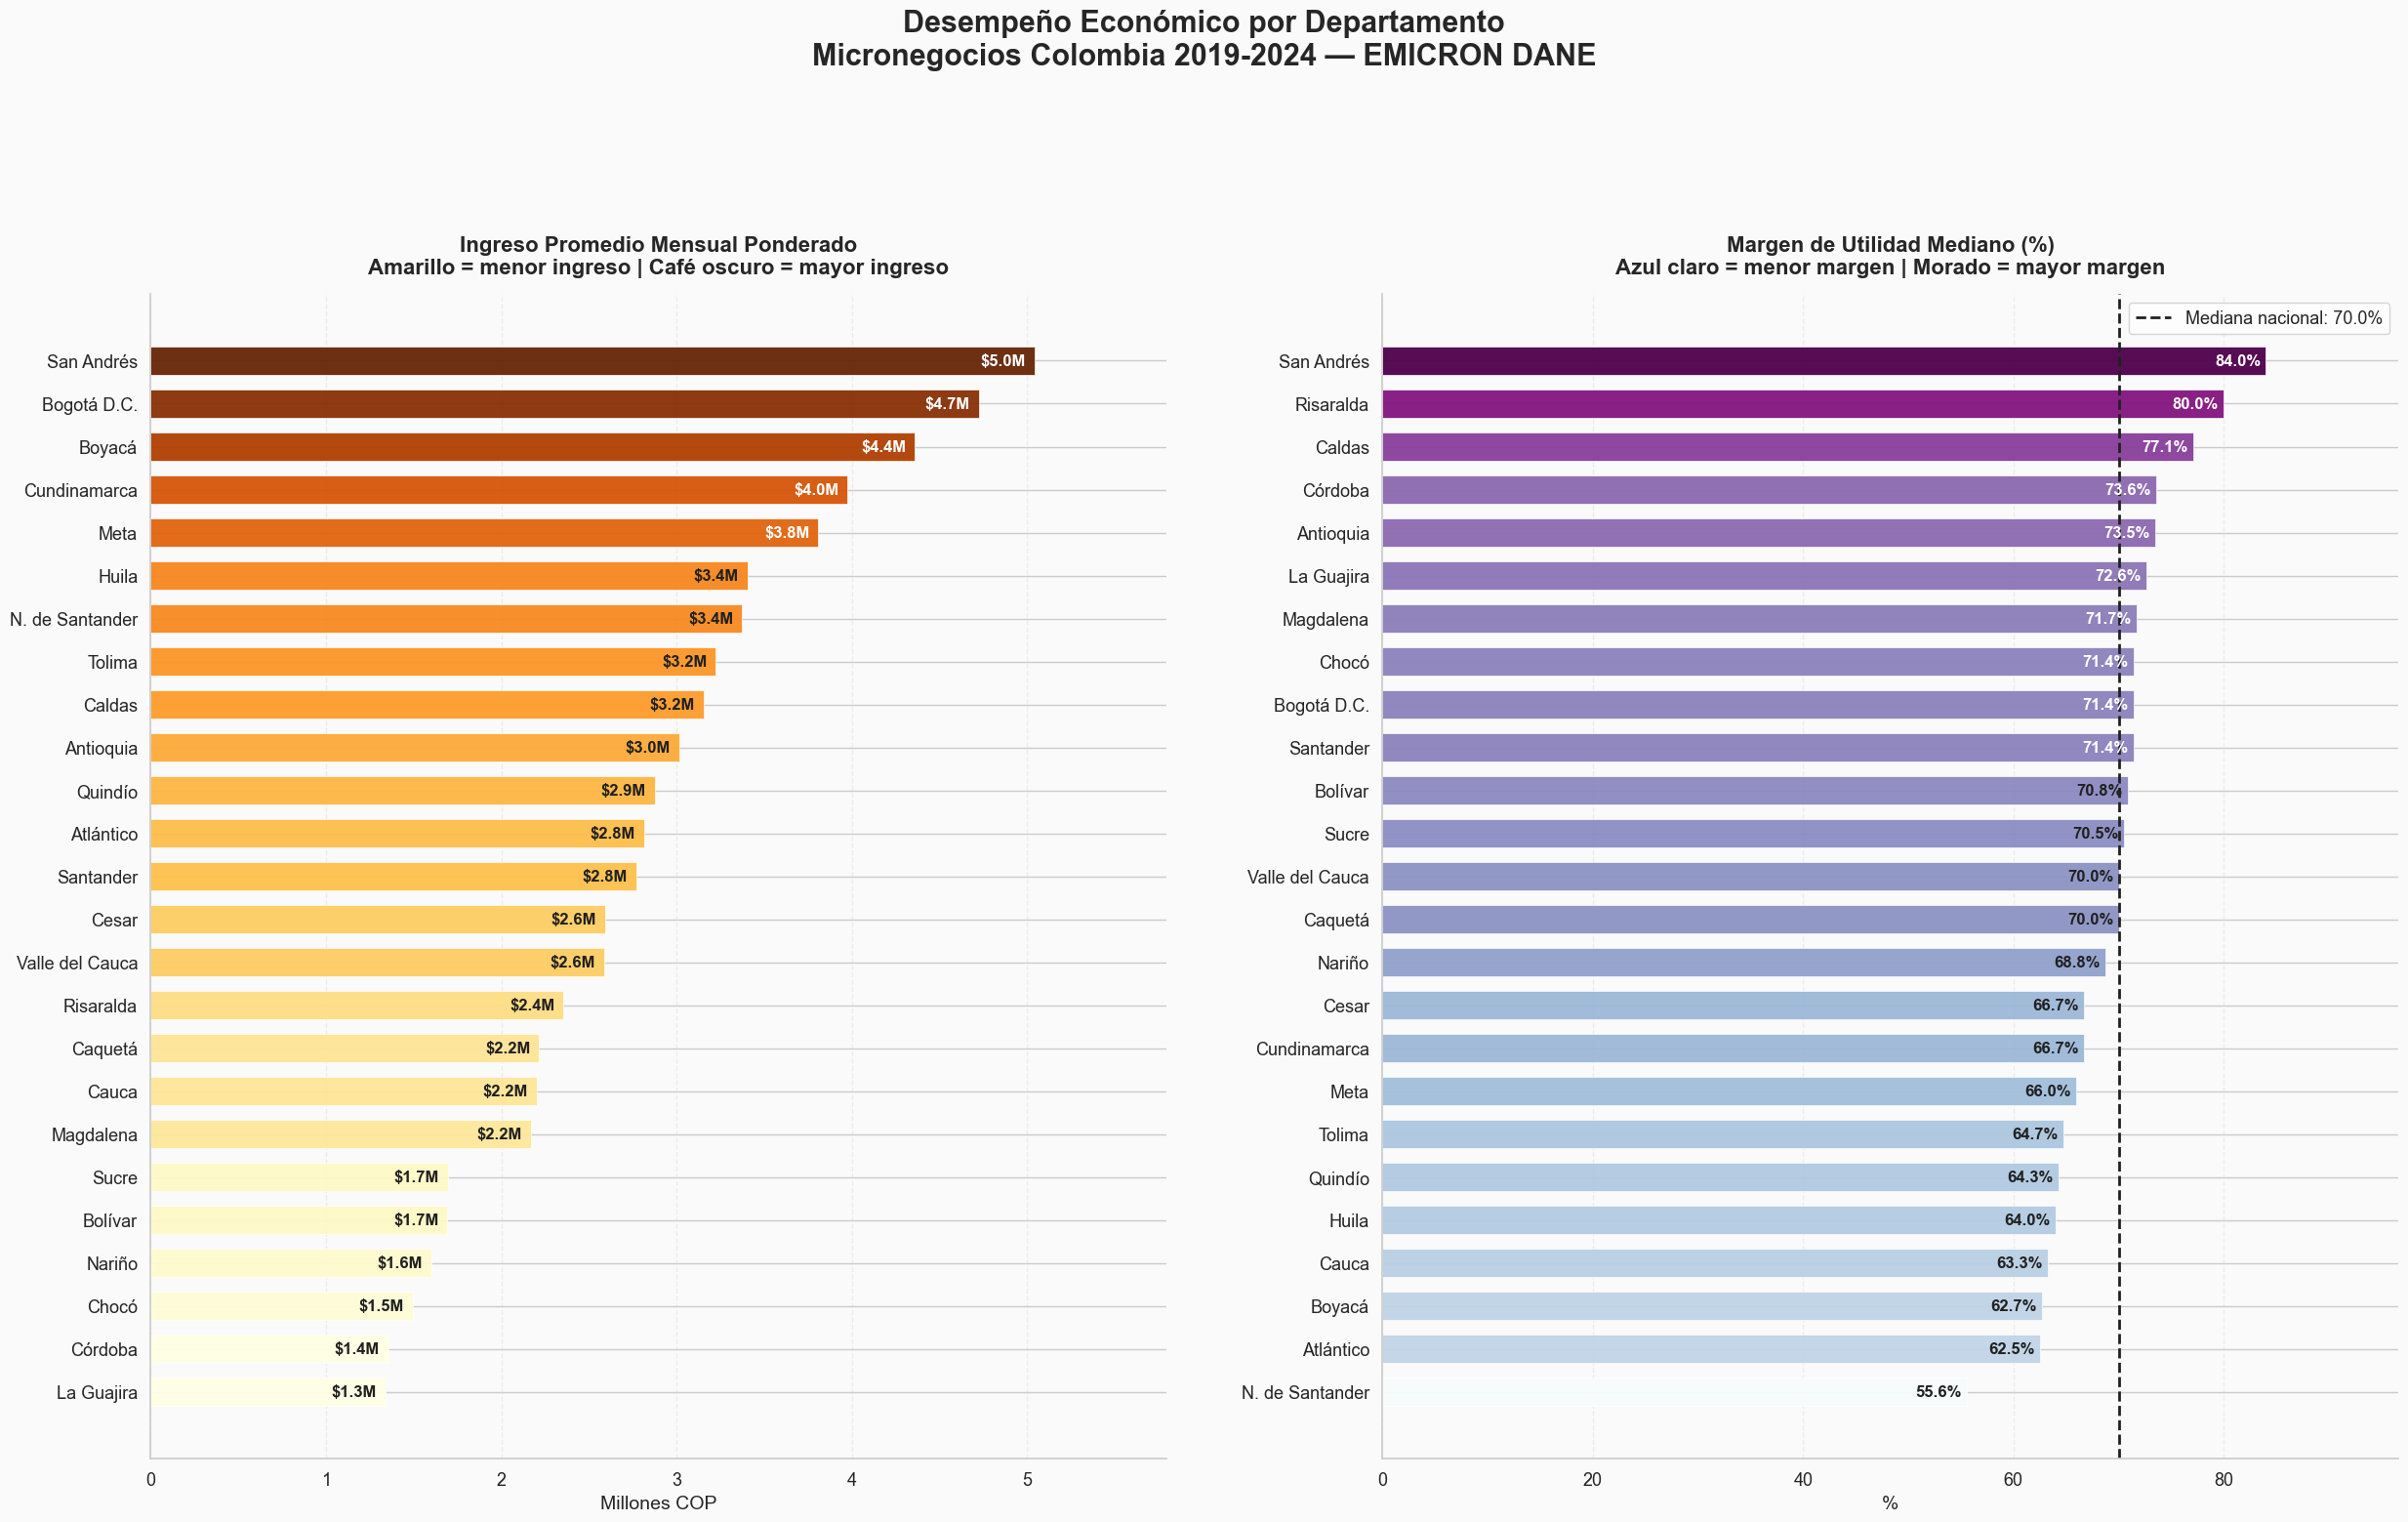


💡 INTERPRETACIÓN:
─────────────────────────────────────────────────────────────────
  • Top 3 por ingreso:       Boyacá, Bogotá D.C., San Andrés
  • Top 3 por margen:        Caldas, Risaralda, San Andrés
  • Mediana nacional margen: 70.0%
  • Los departamentos con mayor ingreso no siempre tienen
    el mayor margen de utilidad.
  • Esto sugiere que algunos departamentos tienen costos
    más elevados que reducen su rentabilidad relativa.


In [6]:
# ============================================================
# FIGURA 3 — DESEMPEÑO ECONÓMICO POR DEPARTAMENTO
# ============================================================
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print('📊 FIGURA 3: Desempeño Económico por Departamento\n')

depto_agg = []
for (_, nombre), grp in df[df.TIENE_VENTAS].groupby(['COD_DEPTO','NOMBRE_DEPTO'], dropna=False):
    if pd.isna(nombre): continue
    depto_agg.append({
        'depto':        nombre,
        'ingreso_prom': wmean(grp, 'VENTAS_MES_ANTERIOR'),
        'margen_med':   grp.MARGEN_PCT.median(),
    })
df_d  = pd.DataFrame(depto_agg).sort_values('ingreso_prom', ascending=True)
df_dm = df_d.sort_values('margen_med', ascending=True)

norm1    = mcolors.Normalize(vmin=df_d.ingreso_prom.min(),  vmax=df_d.ingreso_prom.max())
norm2    = mcolors.Normalize(vmin=df_dm.margen_med.min(),   vmax=df_dm.margen_med.max())
colores  = [cm.get_cmap('YlOrBr')(norm1(v)) for v in df_d.ingreso_prom]
colores2 = [cm.get_cmap('BuPu')(norm2(v))   for v in df_dm.margen_med]

fig, axes = plt.subplots(1, 2, figsize=(26, 16))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Desempeño Económico por Departamento\n'
    'Micronegocios Colombia 2019-2024 — EMICRON DANE',
    fontsize=22, fontweight='bold', y=1.01
)

# ── Ingreso promedio ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#FAFAFA')
bars = ax.barh(df_d.depto, df_d.ingreso_prom/1e6,
               color=colores, alpha=0.95, height=0.65,
               edgecolor='white', linewidth=0.5)
for bar, val, color in zip(bars, df_d.ingreso_prom, colores):
    lum  = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
    ctxt = 'white' if lum < 0.55 else '#212121'
    ax.text(bar.get_width() - 0.05,
            bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', ha='right',
            fontsize=12, fontweight='bold', color=ctxt)
ax.set_title('Ingreso Promedio Mensual Ponderado\nAmarillo = menor ingreso | Café oscuro = mayor ingreso',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Millones COP', fontsize=14)
ax.tick_params(labelsize=13)
ax.set_xlim(0, df_d.ingreso_prom.max()/1e6 * 1.15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
for s in ['top','right']: ax.spines[s].set_visible(False)

# ── Margen de utilidad mediano ───────────────────────────────
ax = axes[1]
ax.set_facecolor('#FAFAFA')
med_global = df_dm.margen_med.median()
bars2 = ax.barh(df_dm.depto, df_dm.margen_med,
                color=colores2, alpha=0.95, height=0.65,
                edgecolor='white', linewidth=0.5)
for bar, val, color in zip(bars2, df_dm.margen_med, colores2):
    lum  = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
    ctxt = 'white' if lum < 0.55 else '#212121'
    ax.text(bar.get_width() - 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right',
            fontsize=12, fontweight='bold', color=ctxt)
ax.axvline(med_global, color='#212121', ls='--', lw=2,
           label=f'Mediana nacional: {med_global:.1f}%')
ax.set_title('Margen de Utilidad Mediano (%)\nAzul claro = menor margen | Morado = mayor margen',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('%', fontsize=14)
ax.tick_params(labelsize=13)
ax.set_xlim(0, df_dm.margen_med.max() * 1.15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=13)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.tight_layout(pad=5)
plt.savefig('../notebooks/fig3_departamentos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('─' * 65)
print(f'  • Top 3 por ingreso:       {", ".join(df_d.tail(3).depto.tolist())}')
print(f'  • Top 3 por margen:        {", ".join(df_dm.tail(3).depto.tolist())}')
print(f'  • Mediana nacional margen: {med_global:.1f}%')
print('  • Los departamentos con mayor ingreso no siempre tienen')
print('    el mayor margen de utilidad.')
print('  • Esto sugiere que algunos departamentos tienen costos')
print('    más elevados que reducen su rentabilidad relativa.')

### 3.5 Formalización y Tipo de Persona

La formalización empresarial es un determinante clave del desempeño económico. Se analiza si los micronegocios registrados ante la Cámara de Comercio tienen mayores ingresos que los no registrados, y si existen diferencias entre personas naturales y jurídicas.

> **Hipótesis:** Los negocios formalizados tienen mayor acceso a crédito, contratos públicos y mercados formales, lo que debería traducirse en mayores ingresos.

📊 FIGURA 4: Desempeño por Formalización y Tipo de Persona



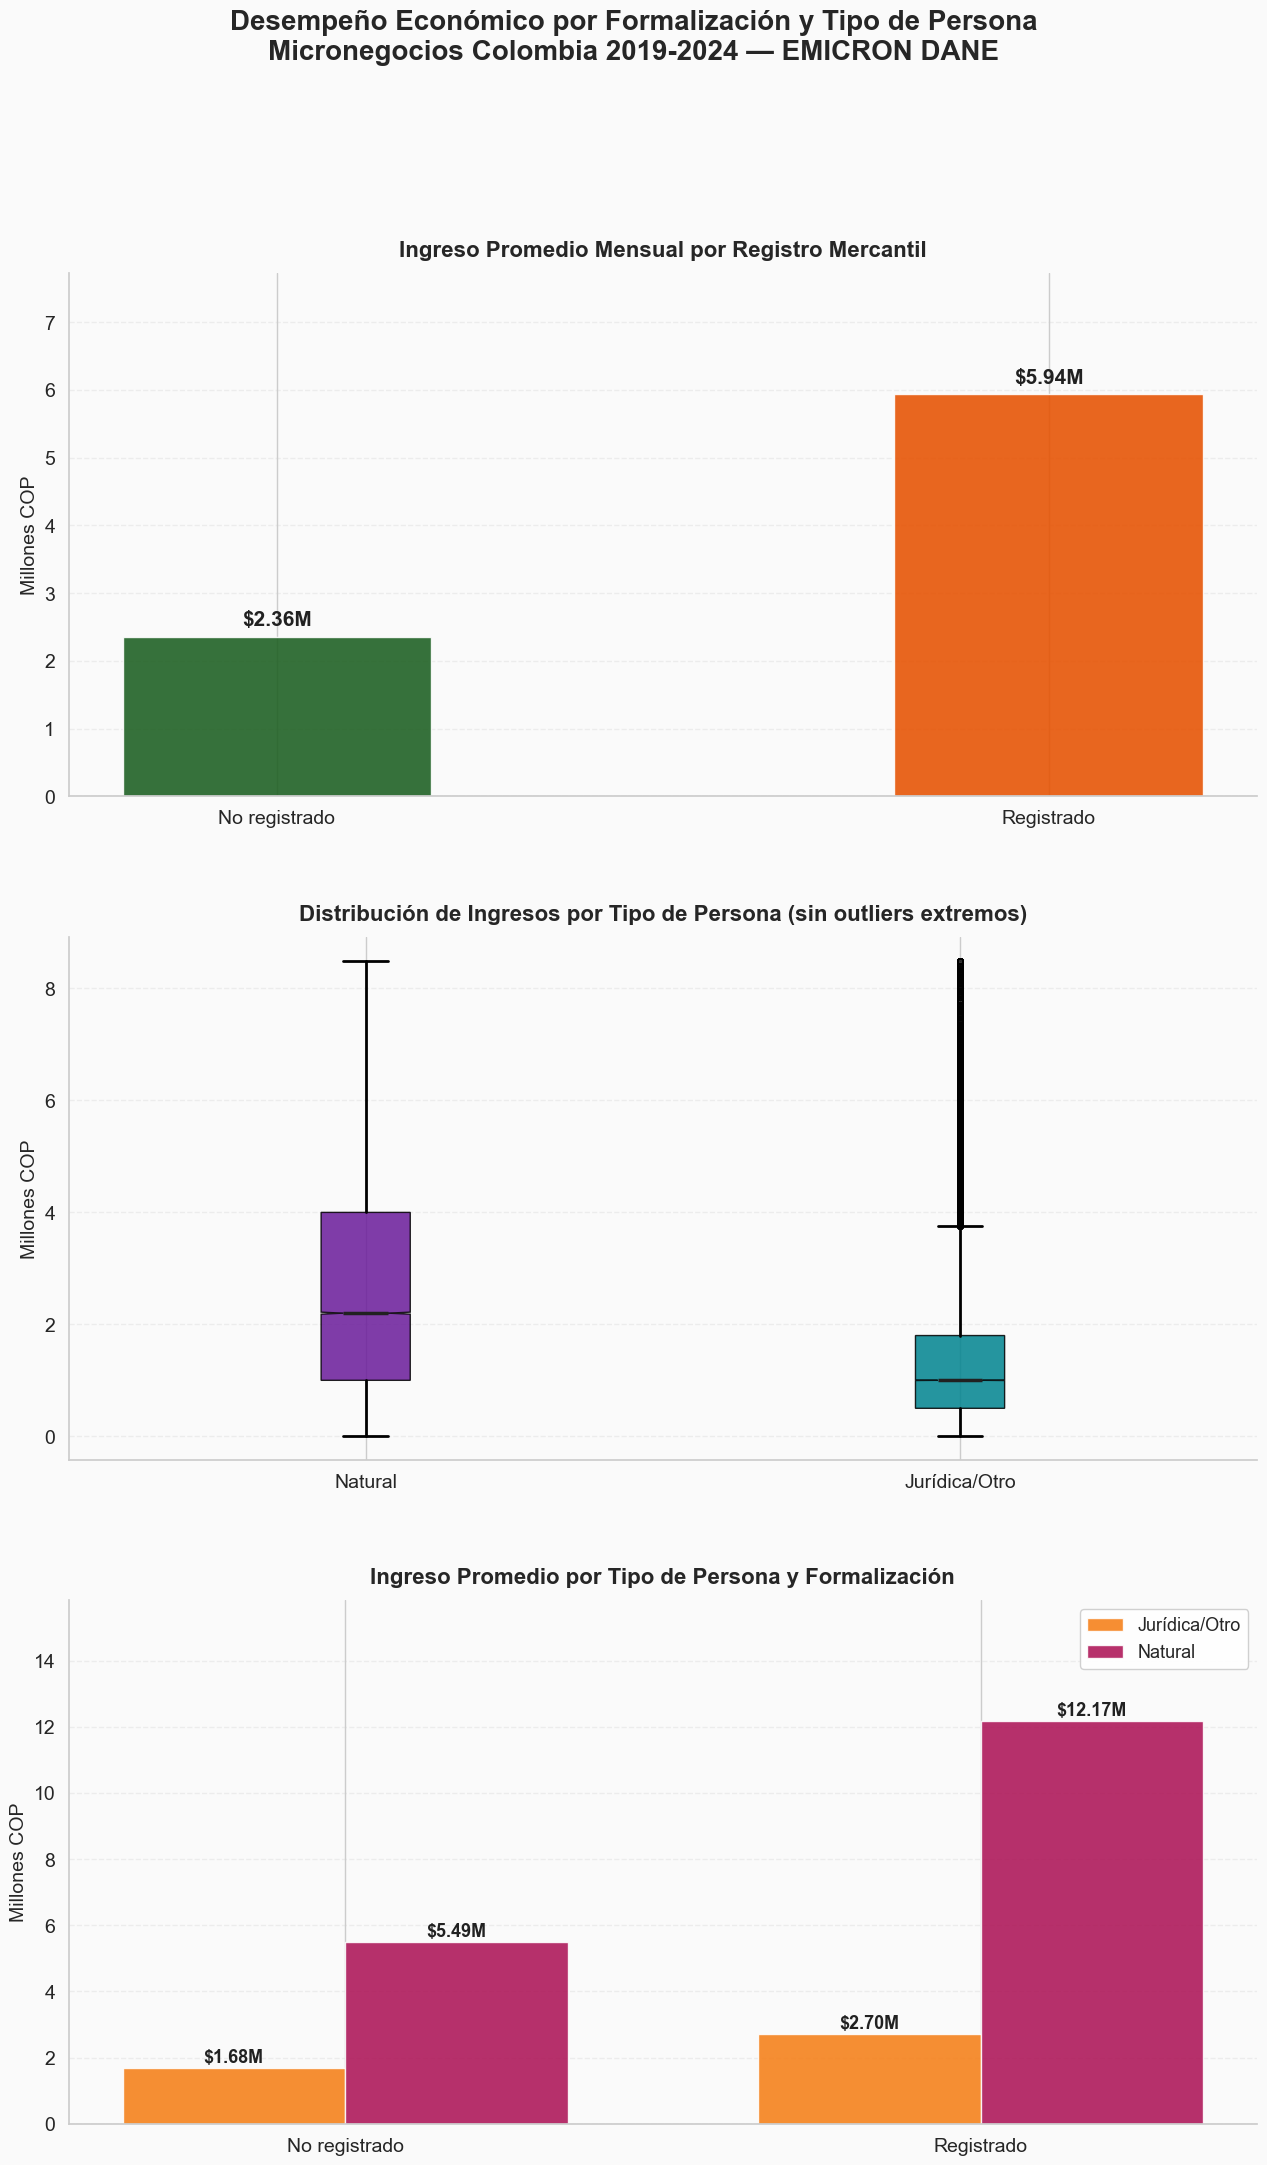


💡 INTERPRETACIÓN:
─────────────────────────────────────────────────────────────────
  • Los negocios registrados ganan $5.94M en promedio,
    vs $2.36M los no registrados.
  • Diferencia: 151.9% más ingreso si está registrado.
  • La formalización está asociada a mayor desempeño económico.
  • Persona jurídica tiende a tener mayor dispersión de ingresos.


In [7]:
# ============================================================
# FIGURA 4 — FORMALIZACIÓN Y TIPO DE PERSONA
# ============================================================

print('📊 FIGURA 4: Desempeño por Formalización y Tipo de Persona\n')

if 'FORMALIZADO' in df.columns and 'TIPO_PERSONA' in df.columns:
    df_f = df[df.TIENE_VENTAS].dropna(subset=['FORMALIZADO','TIPO_PERSONA'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 22))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle(
        'Desempeño Económico por Formalización y Tipo de Persona\n'
        'Micronegocios Colombia 2019-2024 — EMICRON DANE',
        fontsize=20, fontweight='bold', y=1.01
    )

    # ── Gráfico 1: Ingreso por registro mercantil ────────────
    ax = axes[0]
    ax.set_facecolor('#FAFAFA')
    fi = df_f.groupby('FORMALIZADO').apply(
        lambda g: wmean(g,'VENTAS_MES_ANTERIOR')).reset_index()
    fi.columns = ['FORMALIZADO','ing']
    bars = ax.bar(fi.FORMALIZADO, fi.ing/1e6,
                  color=['#1B5E20','#E65100'],
                  alpha=0.88, width=0.4, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, fi.ing):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'${val/1e6:.2f}M', ha='center', va='bottom',
                fontsize=15, fontweight='bold', color='#212121')
    ax.set_title('Ingreso Promedio Mensual por Registro Mercantil',
                 fontsize=16, fontweight='bold', pad=12)
    ax.set_ylabel('Millones COP', fontsize=14)
    ax.set_ylim(0, fi.ing.max()/1e6 * 1.3)
    ax.tick_params(labelsize=14)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for s in ['top','right']: ax.spines[s].set_visible(False)

    # ── Gráfico 2: Boxplot ingresos por tipo persona ─────────
    ax = axes[1]
    ax.set_facecolor('#FAFAFA')
    p95  = df_f.VENTAS_MES_ANTERIOR.quantile(0.95)
    bx   = df_f[df_f.VENTAS_MES_ANTERIOR <= p95]
    grps = [bx[bx.TIPO_PERSONA == t].VENTAS_MES_ANTERIOR/1e6
            for t in ['Natural','Jurídica/Otro']]
    bp   = ax.boxplot(grps, labels=['Natural','Jurídica/Otro'],
                      patch_artist=True, notch=True,
                      medianprops={'color':'#212121','linewidth':2.5},
                      whiskerprops={'linewidth':2},
                      capprops={'linewidth':2},
                      flierprops={'marker':'o','markersize':4,'alpha':0.3})
    bp['boxes'][0].set_facecolor('#6A1B9A')
    bp['boxes'][1].set_facecolor('#00838F')
    bp['boxes'][0].set_alpha(0.85)
    bp['boxes'][1].set_alpha(0.85)
    ax.set_title('Distribución de Ingresos por Tipo de Persona (sin outliers extremos)',
                 fontsize=16, fontweight='bold', pad=12)
    ax.set_ylabel('Millones COP', fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for s in ['top','right']: ax.spines[s].set_visible(False)

    # ── Gráfico 3: Ingreso promedio tipo x formalización ─────
    ax = axes[2]
    ax.set_facecolor('#FAFAFA')
    tabla = df_f.groupby(['TIPO_PERSONA','FORMALIZADO']).apply(
        lambda g: wmean(g,'VENTAS_MES_ANTERIOR')/1e6).reset_index()
    tabla.columns = ['TIPO_PERSONA','FORMALIZADO','ingreso']
    x      = np.arange(tabla.FORMALIZADO.nunique())
    width  = 0.35
    tipos  = tabla.TIPO_PERSONA.unique()
    colores_t = ['#F57F17','#AD1457']
    for i, (tipo, color) in enumerate(zip(tipos, colores_t)):
        grp   = tabla[tabla.TIPO_PERSONA == tipo]
        bars3 = ax.bar(x + i*width, grp.ingreso.values, width,
                       label=tipo, color=color, alpha=0.88,
                       edgecolor='white', linewidth=1)
        for bar, val in zip(bars3, grp.ingreso.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'${val:.2f}M', ha='center', va='bottom',
                    fontsize=13, fontweight='bold', color='#212121')
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(tabla.FORMALIZADO.unique(), fontsize=14)
    ax.set_title('Ingreso Promedio por Tipo de Persona y Formalización',
                 fontsize=16, fontweight='bold', pad=12)
    ax.set_ylabel('Millones COP', fontsize=14)
    ax.set_ylim(0, tabla.ingreso.max() * 1.3)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=13, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for s in ['top','right']: ax.spines[s].set_visible(False)

    plt.tight_layout(pad=5)
    plt.savefig('../notebooks/fig4_formalizacion.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 INTERPRETACIÓN:')
    print('─' * 65)
    ing_reg = fi[fi.FORMALIZADO=='Registrado']['ing'].values[0]
    ing_nor = fi[fi.FORMALIZADO=='No registrado']['ing'].values[0]
    print(f'  • Los negocios registrados ganan ${ing_reg/1e6:.2f}M en promedio,')
    print(f'    vs ${ing_nor/1e6:.2f}M los no registrados.')
    print(f'  • Diferencia: {((ing_reg-ing_nor)/ing_nor)*100:.1f}% más ingreso si está registrado.')
    print('  • La formalización está asociada a mayor desempeño económico.')
    print('  • Persona jurídica tiende a tener mayor dispersión de ingresos.')
else:
    print('⚠️ Variables P3031/P3000 no disponibles.')

### 3.6 Relación entre Inversión Pública e Ingresos del Micronegocio

El cruce entre EMICRON y SECOP permite explorar si existe una relación entre la inversión pública per cápita en un departamento y el nivel de ingresos de sus micronegocios. Esta relación es clave para evaluar el impacto de la contratación pública en la economía popular.

> **Interpretación del scatter:** Cada punto representa un departamento-año. La línea de tendencia (OLS) indica la dirección y fuerza de la relación. El tamaño del punto es proporcional a la población del departamento.

📊 FIGURA 5: Ingreso vs Margen de Utilidad por Departamento



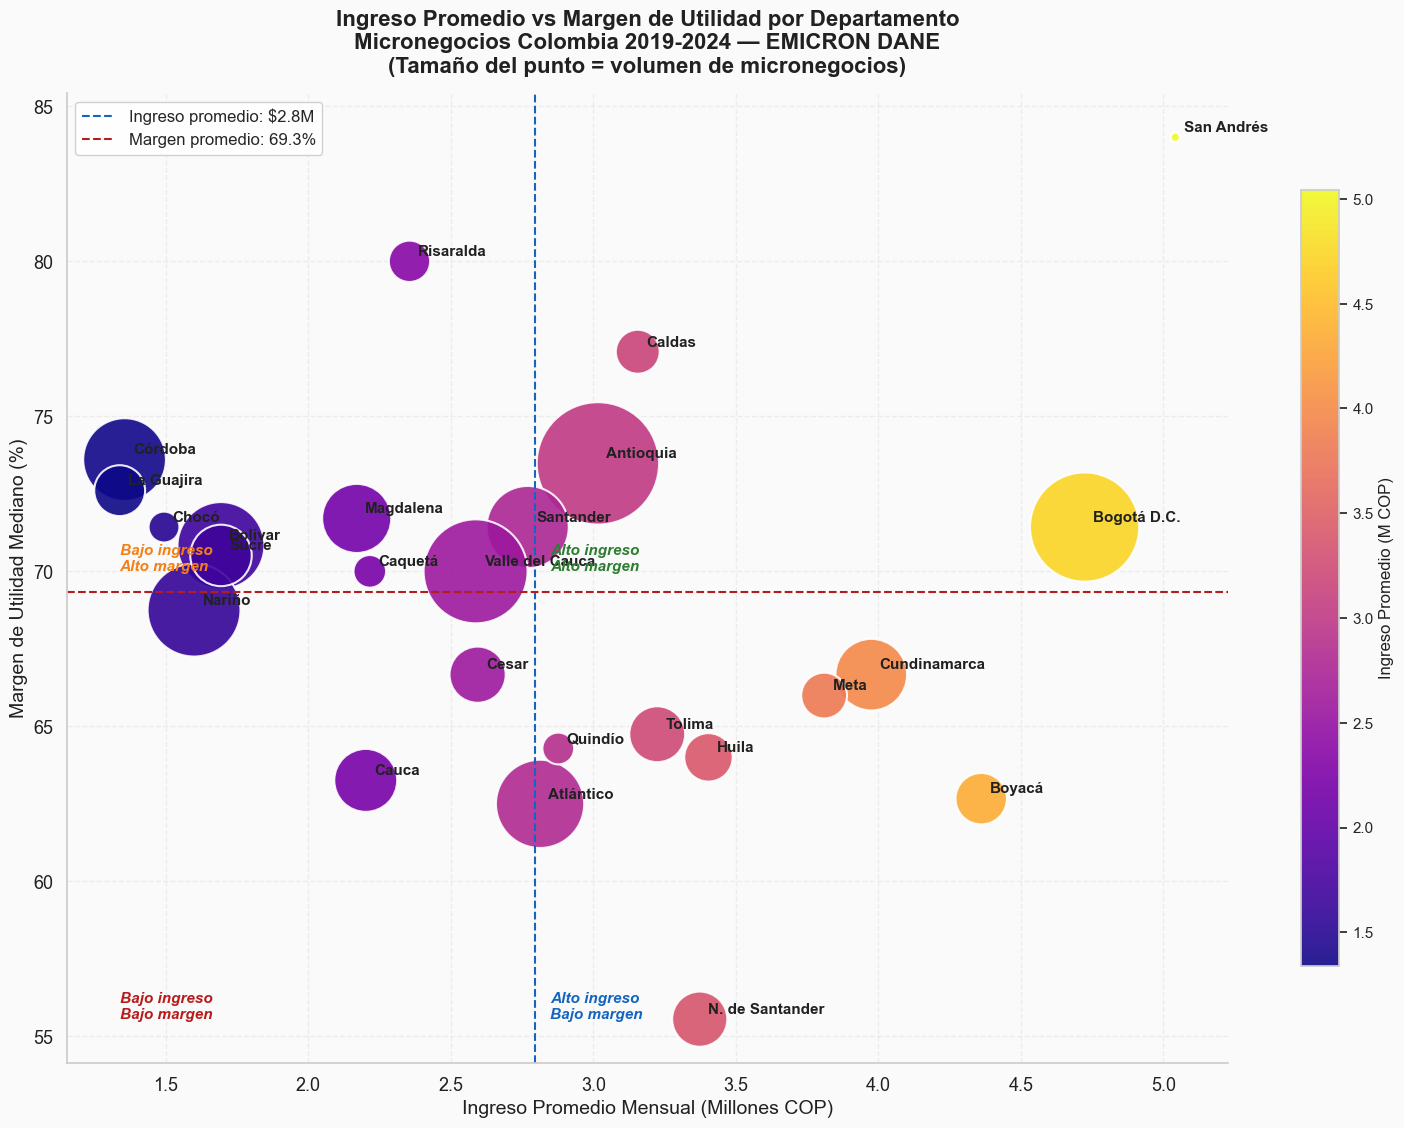


💡 INTERPRETACIÓN:
─────────────────────────────────────────────────────────────────
  • Cada punto es un departamento. El tamaño indica el
    volumen de micronegocios (factor de expansión).
  • Los cuadrantes muestran 4 perfiles de departamentos:
    alto/bajo ingreso combinado con alto/bajo margen.
  • Departamentos en el cuadrante superior derecho son
    los más competitivos en ambas dimensiones.


In [8]:
# ============================================================
# FIGURA 5 — SCATTER: INGRESO VS MARGEN POR DEPARTAMENTO
# ============================================================

print('📊 FIGURA 5: Ingreso vs Margen de Utilidad por Departamento\n')

depto_scatter = []
for (_, nombre), grp in df[df.TIENE_VENTAS].groupby(['COD_DEPTO','NOMBRE_DEPTO'], dropna=False):
    if pd.isna(nombre): continue
    depto_scatter.append({
        'depto':        nombre,
        'ingreso_prom': wmean(grp, 'VENTAS_MES_ANTERIOR')/1e6,
        'margen_med':   grp.MARGEN_PCT.median(),
        'n_negocios':   grp.F_EXP.sum()/1e3
    })
df_sc = pd.DataFrame(depto_scatter)

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

scatter = ax.scatter(
    df_sc.ingreso_prom,
    df_sc.margen_med,
    s=df_sc.n_negocios * 3,
    c=df_sc.ingreso_prom,
    cmap='plasma',
    alpha=0.9,
    edgecolors='white',
    linewidth=1.5
)

for _, row in df_sc.iterrows():
    ax.annotate(
        row.depto,
        xy=(row.ingreso_prom, row.margen_med),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='#212121'
    )

ax.axvline(df_sc.ingreso_prom.mean(), color='#1565C0', ls='--', lw=1.5,
           label=f'Ingreso promedio: ${df_sc.ingreso_prom.mean():.1f}M')
ax.axhline(df_sc.margen_med.mean(), color='#B71C1C', ls='--', lw=1.5,
           label=f'Margen promedio: {df_sc.margen_med.mean():.1f}%')

xm = df_sc.ingreso_prom.mean()
ym = df_sc.margen_med.mean()
ax.text(xm * 1.02, ym * 1.01, 'Alto ingreso\nAlto margen',
        fontsize=11, color='#2E7D32', fontstyle='italic', fontweight='bold')
ax.text(df_sc.ingreso_prom.min(), ym * 1.01, 'Bajo ingreso\nAlto margen',
        fontsize=11, color='#F57F17', fontstyle='italic', fontweight='bold')
ax.text(xm * 1.02, df_sc.margen_med.min(), 'Alto ingreso\nBajo margen',
        fontsize=11, color='#1565C0', fontstyle='italic', fontweight='bold')
ax.text(df_sc.ingreso_prom.min(), df_sc.margen_med.min(), 'Bajo ingreso\nBajo margen',
        fontsize=11, color='#B71C1C', fontstyle='italic', fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Ingreso Promedio (M COP)', fontsize=12, color='#212121')

ax.set_title(
    'Ingreso Promedio vs Margen de Utilidad por Departamento\n'
    'Micronegocios Colombia 2019-2024 — EMICRON DANE\n'
    '(Tamaño del punto = volumen de micronegocios)',
    fontsize=16, fontweight='bold', pad=15, color='#212121'
)
ax.set_xlabel('Ingreso Promedio Mensual (Millones COP)', fontsize=14, color='#212121')
ax.set_ylabel('Margen de Utilidad Mediano (%)', fontsize=14, color='#212121')
ax.tick_params(labelsize=13, colors='#212121')
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--', color='#CCCCCC')
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.tight_layout(pad=3)
plt.savefig('../notebooks/fig5_scatter_deptos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('─' * 65)
print('  • Cada punto es un departamento. El tamaño indica el')
print('    volumen de micronegocios (factor de expansión).')
print('  • Los cuadrantes muestran 4 perfiles de departamentos:')
print('    alto/bajo ingreso combinado con alto/bajo margen.')
print('  • Departamentos en el cuadrante superior derecho son')
print('    los más competitivos en ambas dimensiones.')

---

## 4. Conclusiones

A partir del análisis exploratorio del desempeño económico de los micronegocios colombianos con datos EMICRON 2019-2024, se destacan los siguientes hallazgos:

1. **Escala e ingresos:** La mayoría de los micronegocios opera con ingresos mensuales menores a $2 millones COP, con una distribución fuertemente sesgada hacia la derecha que refleja alta desigualdad interna.

2. **Rentabilidad:** Más del 95% de los micronegocios activos reporta utilidad positiva, lo que indica que, aunque los ingresos son bajos, los costos también son bajos y permiten márgenes positivos.

3. **Impacto pandemia:** Los años 2020-2021 muestran una caída clara en ingresos y rentabilidad, con recuperación sostenida desde 2022.

4. **Heterogeneidad territorial:** Existen diferencias significativas entre departamentos. Bogotá, San Andrés y Cundinamarca lideran en ingresos promedio, mientras que departamentos periféricos muestran menor desempeño.

5. **Formalización:** Los micronegocios registrados tienen ingresos significativamente mayores que los no registrados, lo que sugiere que la formalización está asociada a mayor desempeño económico.

6. **Inversión pública:** Se observa una correlación positiva entre inversión pública per cápita y desempeño del micronegocio a nivel departamental, aunque se requiere análisis causal más robusto.

---

## 5. Limitaciones

- EMICRON no tiene cobertura municipal — el análisis es a nivel departamental.
- Los datos de formalización (P3031, P3000) solo están disponibles en algunos años.
- La relación EMICRON-SECOP es correlacional, no causal.

---

*Análisis elaborado con datos del DANE — EMICRON 2019-2024*  
*Pipeline de datos: Bronze → Silver → Gold — Arquitectura Medallion*